# CIFAR-10 Training: ResNet-18 vs Neural ODE
Train either a ResNet-18 or a Neural ODE classifier on CIFAR-10.

In [1]:
import os
import math
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.autograd import Variable

from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt
from PIL import Image

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

## Settings

In [2]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 1
LEARNING_RATE = 0.001
BATCH_SIZE = 128
NUM_EPOCHS = 5

# Architecture
NUM_FEATURES = 32 * 32 * 3
NUM_CLASSES = 10

# Device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

GRAYSCALE = False

# Choose model: 'resnet', 'node', 'cnn', 'mlp'
MODEL_TYPE = 'resnet'  # <--- change this to switch models

print(f"Using device: {DEVICE}")
print(f"Model type: {MODEL_TYPE}")

Using device: mps
Model type: resnet


## Dataset

In [3]:
##########################
### CIFAR-10 DATASET
##########################

cifar10_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(root='data',
                                  train=True,
                                  transform=cifar10_transform,
                                  download=True)

test_dataset = datasets.CIFAR10(root='data',
                                 train=False,
                                 transform=cifar10_transform)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

# Sanity check
for images, labels in train_loader:
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

100%|██████████| 170M/170M [00:52<00:00, 3.23MB/s] 
/Users/dazedinthecity/ml/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Image batch dimensions: torch.Size([128, 3, 32, 32])
Image label dimensions: torch.Size([128])


## Model Definitions
### 1. ResNet-18

In [4]:
##########################
### RESNET-18
##########################

def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes, grayscale):
        self.inplanes = 64
        in_dim = 1 if grayscale else 3
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(in_dim, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, (2. / n) ** .5)
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # avgpool disabled for MNIST (spatial dims already 1x1)
        x = x.view(x.size(0), -1)
        logits = self.fc(x)
        probas = F.softmax(logits, dim=1)
        return logits, probas


def resnet18(num_classes):
    """Constructs a ResNet-18 model."""
    return ResNet(block=BasicBlock,
                  layers=[2, 2, 2, 2],
                  num_classes=num_classes,
                  grayscale=GRAYSCALE)

### 2. --Broken-- Neural ODE

In [5]:
##########################
### ODE SOLVER (Euler)
##########################

# cr. msurtsukov
# def ode_solve(z0, t0, t1, f):
#     """
#     Simplest Euler ODE initial value solver.
#     """
#     h_max = 0.05
#     n_steps = math.ceil((abs(t1 - t0) / h_max).max().item())
#     h = (t1 - t0) / n_steps
#     t = t0
#     z = z0
#     for i_step in range(n_steps):
#         z = z + h * f(z, t)
#         t = t + h
#     return z

In [6]:
##########################
### ODE SOLVER (4th order rk)
##########################

def ode_solve(z0, t0, t1, f):
    """
    4th Order Runge-Kutta ODE initial value solver.
    """
    h_max = 0.05
    n_steps = math.ceil((abs(t1 - t0) / h_max).max().item())
    h = (t1 - t0) / n_steps
    t = t0
    z = z0
    for i_step in range(n_steps):
        k1 = f(z, t)
        k2 = f(z + h * k1 / 2, t + h / 2)
        k3 = f(z + h * k2 / 2, t + h / 2)
        k4 = f(z + h * k3, t + h)
        z = z + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        t = t + h
    return z

In [7]:
##########################
### ODEF BASE CLASS
##########################

class ODEF(nn.Module):
    def forward_with_grad(self, z, t, grad_outputs):
        """Compute f and a*df/dz, a*df/dp, a*df/dt"""
        batch_size = z.shape[0]
        out = self.forward(z, t)
        a = grad_outputs
        adfdz, adfdt, *adfdp = torch.autograd.grad(
            (out,), (z, t) + tuple(self.parameters()), grad_outputs=(a),
            allow_unused=True, retain_graph=True
        )
        if adfdp is not None:
            adfdp = torch.cat([p_grad.flatten() for p_grad in adfdp]).unsqueeze(0)
            adfdp = adfdp.expand(batch_size, -1) / batch_size
        if adfdt is not None:
            adfdt = adfdt.expand(batch_size, 1) / batch_size
        return out, adfdz, adfdt, adfdp

    def flatten_parameters(self):
        p_shapes = []
        flat_parameters = []
        for p in self.parameters():
            p_shapes.append(p.size())
            flat_parameters.append(p.flatten())
        return torch.cat(flat_parameters)

In [8]:
##########################
### ADJOINT METHOD
##########################

class ODEAdjoint(torch.autograd.Function):
    @staticmethod
    def forward(ctx, z0, t, flat_parameters, func):
        assert isinstance(func, ODEF)
        bs, *z_shape = z0.size()
        time_len = t.size(0)

        with torch.no_grad():
            z = torch.zeros(time_len, bs, *z_shape).to(z0)
            z[0] = z0
            for i_t in range(time_len - 1):
                z0 = ode_solve(z0, t[i_t], t[i_t + 1], func)
                z[i_t + 1] = z0

        ctx.func = func
        ctx.save_for_backward(t, z.clone(), flat_parameters)
        return z

    @staticmethod
    def backward(ctx, dLdz):
        func = ctx.func
        t, z, flat_parameters = ctx.saved_tensors
        time_len, bs, *z_shape = z.size()
        n_dim = np.prod(z_shape)
        n_params = flat_parameters.size(0)

        def augmented_dynamics(aug_z_i, t_i):
            z_i, a = aug_z_i[:, :n_dim], aug_z_i[:, n_dim:2 * n_dim]
            z_i = z_i.view(bs, *z_shape)
            a = a.view(bs, *z_shape)
            with torch.set_grad_enabled(True):
                t_i = t_i.detach().requires_grad_(True)
                z_i = z_i.detach().requires_grad_(True)
                func_eval, adfdz, adfdt, adfdp = func.forward_with_grad(z_i, t_i, grad_outputs=a)
                adfdz = adfdz.to(z_i) if adfdz is not None else torch.zeros(bs, *z_shape).to(z_i)
                adfdp = adfdp.to(z_i) if adfdp is not None else torch.zeros(bs, n_params).to(z_i)
                adfdt = adfdt.to(z_i) if adfdt is not None else torch.zeros(bs, 1).to(z_i)
            func_eval = func_eval.view(bs, n_dim)
            adfdz = adfdz.view(bs, n_dim)
            return torch.cat((func_eval, -adfdz, -adfdp, -adfdt), dim=1)

        dLdz = dLdz.view(time_len, bs, n_dim)
        with torch.no_grad():
            adj_z = torch.zeros(bs, n_dim).to(dLdz)
            adj_p = torch.zeros(bs, n_params).to(dLdz)
            adj_t = torch.zeros(time_len, bs, 1).to(dLdz)

            for i_t in range(time_len - 1, 0, -1):
                z_i = z[i_t]
                t_i = t[i_t]
                f_i = func(z_i, t_i).view(bs, n_dim)

                dLdz_i = dLdz[i_t]
                dLdt_i = torch.bmm(torch.transpose(dLdz_i.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

                adj_z += dLdz_i
                adj_t[i_t] = adj_t[i_t] - dLdt_i

                aug_z = torch.cat((z_i.view(bs, n_dim), adj_z, torch.zeros(bs, n_params).to(z), adj_t[i_t]), dim=-1)
                aug_ans = ode_solve(aug_z, t_i, t[i_t - 1], augmented_dynamics)

                adj_z[:] = aug_ans[:, n_dim:2 * n_dim]
                adj_p[:] += aug_ans[:, 2 * n_dim:2 * n_dim + n_params]
                adj_t[i_t - 1] = aug_ans[:, 2 * n_dim + n_params:]

                del aug_z, aug_ans

            dLdz_0 = dLdz[0]
            dLdt_0 = torch.bmm(torch.transpose(dLdz_0.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]
            adj_z += dLdz_0
            adj_t[0] = adj_t[0] - dLdt_0

        return adj_z.view(bs, *z_shape), adj_t, adj_p, None

In [9]:
##########################
### NEURAL ODE MODULE
##########################

class NeuralODE(nn.Module):
    def __init__(self, func):
        super(NeuralODE, self).__init__()
        assert isinstance(func, ODEF)
        self.func = func

    def forward(self, z0, t=torch.Tensor([0., 1.]), return_whole_sequence=False):
        t = t.to(z0)
        z = ODEAdjoint.apply(z0, t, self.func.flatten_parameters(), self.func)
        if return_whole_sequence:
            return z
        else:
            return z[-1]  # return the state at the final time step


##########################
### ODE DYNAMICS FUNCTION
### (the learned f(z, t))
##########################

class ConvODEFunc(ODEF):
    """
    Convolutional dynamics function for the Neural ODE.
    Operates on feature maps of shape (B, channels, H, W).
    Input and output channels must match so the ODE state is constant-dimension.
    """
    def __init__(self, channels):
        super(ConvODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )

    def forward(self, z, t):
        # t is unused explicitly; the network learns time-independent dynamics.
        # For time-conditioned dynamics you can concatenate a t-channel.
        return self.net(z)


##########################
### FULL ODENet CLASSIFIER
##########################

class ODENet(nn.Module):
    """
    Neural ODE classifier for CIFAR-10.

    Architecture:
      1. Downsample encoder  : Conv 3->64, stride 1; Conv 64->64, stride 2
      2. Neural ODE block    : evolve 64-channel feature map from t=0 to t=1
      3. Classifier head     : AdaptiveAvgPool -> Flatten -> Linear(64, 10)
    """
    def __init__(self, num_classes=10):
        super(ODENet, self).__init__()

        # Encoder: 3x32x32  ->  64x16x16
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),  # 64x32x32
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1, bias=False),  # 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # ODE block: 64x16x16 -> 64x16x16
        self.ode_func = ConvODEFunc(channels=64)
        self.ode_block = NeuralODE(self.ode_func)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # 64x1x1
            nn.Flatten(),                  # 64
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x: B x 3 x 32 x 32
        z0 = self.encoder(x)                  # B x 64 x 16 x 16
        z1 = self.ode_block(z0)               # B x 64 x 16 x 16  (state at t=1)
        logits = self.classifier(z1)           # B x num_classes
        probas = F.softmax(logits, dim=1)
        return logits, probas

### 3. Vanilla CNN

In [10]:
##########################
### MODEL
##########################


class ConvNet(torch.nn.Module):

    def __init__(self, num_classes):
        super(ConvNet, self).__init__()
        
        # calculate same padding:
        # (w - k + 2*p)/s + 1 = o
        # => p = (s(o-1) - w + k)/2
        
        # 32x32x3 => 32x32x8
        self.conv_1 = torch.nn.Conv2d(in_channels=3,
                                      out_channels=8,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1)
        # 32x32x8 => 16x16x8
        self.pool_1 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0)
        # 16x16x8 => 16x16x16
        self.conv_2 = torch.nn.Conv2d(in_channels=8,
                                      out_channels=16,
                                      kernel_size=(3, 3),
                                      stride=(1, 1),
                                      padding=1)
        # 16x16x16 => 8x8x16
        self.pool_2 = torch.nn.MaxPool2d(kernel_size=(2, 2),
                                         stride=(2, 2),
                                         padding=0)

        self.linear_1 = torch.nn.Linear(8*8*16, num_classes)

        # optionally initialize weights from Gaussian;
        # Guassian weight init is not recommended and only for demonstration purposes
        for m in self.modules():
            if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.Linear):
                m.weight.data.normal_(0.0, 0.01)
                m.bias.data.zero_()
                if m.bias is not None:
                    m.bias.detach().zero_()
        
        
    def forward(self, x):
        out = self.conv_1(x)
        out = F.relu(out)
        out = self.pool_1(out)

        out = self.conv_2(out)
        out = F.relu(out)
        out = self.pool_2(out)
        
        logits = self.linear_1(out.view(-1, 8*8*16))
        probas = F.softmax(logits, dim=1)
        return logits, probas

### 4. MLP

In [11]:
##########################
### MODEL
##########################

class MLP(torch.nn.Module):

    def __init__(self, num_features, num_classes):
        super(MLP, self).__init__()
        
        self.linear_1 = torch.nn.Linear(num_features, 128)
        self.linear_2 = torch.nn.Linear(128, 64)
        self.linear_3 = torch.nn.Linear(64, num_classes)

        # weight initialization
        for m in self.modules():
            if isinstance(m, torch.nn.Linear):
                m.weight.data.normal_(0.0, 0.01)
                m.bias.data.zero_()
                if m.bias is not None:
                    m.bias.detach().zero_()

    def forward(self, x):
        x = x.view(-1, NUM_FEATURES)  # flatten 32x32x3 -> 3072
        
        out = self.linear_1(x)
        out = F.relu(out)
        
        out = self.linear_2(out)
        out = F.relu(out)
        
        logits = self.linear_3(out)
        probas = F.softmax(logits, dim=1)
        return logits, probas

## Initialise Model & Optimizer

In [12]:
torch.manual_seed(RANDOM_SEED)

if MODEL_TYPE == 'resnet':
    model = resnet18(NUM_CLASSES)
elif MODEL_TYPE == 'node':
    model = ODENet(num_classes=NUM_CLASSES)
elif MODEL_TYPE == 'cnn':
    model = ConvNet(num_classes=NUM_CLASSES)
elif MODEL_TYPE == 'mlp':
    model = MLP(num_features=NUM_FEATURES, num_classes=NUM_CLASSES)
else:
    raise ValueError(f"Unknown MODEL_TYPE '{MODEL_TYPE}'. Choose 'resnet' or 'node'.")

model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_TYPE}  |  Trainable parameters: {total_params:,}")

Model: resnet  |  Trainable parameters: 11,181,642


## Training Loop

In [13]:
def compute_accuracy(model, data_loader, device):
    correct_pred, num_examples = 0, 0
    model.eval()
    with torch.set_grad_enabled(False):
        for features, targets in data_loader:
            features = features.to(device)
            targets = targets.to(device)
            logits, probas = model(features)
            _, predicted_labels = torch.max(probas, 1)
            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float() / num_examples * 100


# start_time = time.time()

# for epoch in range(NUM_EPOCHS):
#     model.train()
#     for batch_idx, (features, targets) in enumerate(train_loader):
#         features = features.to(DEVICE)
#         targets = targets.to(DEVICE)

#         ### FORWARD AND BACK PROP
#         logits, probas = model(features)
#         cost = F.cross_entropy(logits, targets)
#         optimizer.zero_grad()
#         cost.backward()

#         ### UPDATE MODEL PARAMETERS
#         optimizer.step()

#         ### LOGGING
#         if not batch_idx % 50:
#             print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
#                   % (epoch + 1, NUM_EPOCHS, batch_idx, len(train_loader), cost))

#     model.eval()
#     with torch.set_grad_enabled(False):
#         train_acc = compute_accuracy(model, train_loader, device=DEVICE)
#         print('Epoch: %03d/%03d | Train Acc: %.3f%%' % (epoch + 1, NUM_EPOCHS, train_acc))

#     print('Time elapsed: %.2f min' % ((time.time() - start_time) / 60))

# print('Total Training Time: %.2f min' % ((time.time() - start_time) / 60))

## Evaluation

In [14]:
# with torch.set_grad_enabled(False):
#     test_acc = compute_accuracy(model, test_loader, device=DEVICE)
#     print(f'[{MODEL_TYPE.upper()}] Test accuracy: {test_acc:.2f}%')

## All & compare

Model: resnet  |  Trainable parameters: 11,181,642


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_20898/2702466063.py:42: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'


Epoch: 001/005 | Batch 0000/0391 | Cost: 2.5472
Epoch: 001/005 | Batch 0050/0391 | Cost: 1.6036
Epoch: 001/005 | Batch 0100/0391 | Cost: 1.2849
Epoch: 001/005 | Batch 0150/0391 | Cost: 1.4570
Epoch: 001/005 | Batch 0200/0391 | Cost: 1.4248
Epoch: 001/005 | Batch 0250/0391 | Cost: 1.2227
Epoch: 001/005 | Batch 0300/0391 | Cost: 1.3562
Epoch: 001/005 | Batch 0350/0391 | Cost: 0.9709
Epoch: 001/005 | Train Acc: 58.480%
Time elapsed: 0.49 min
Epoch: 002/005 | Batch 0000/0391 | Cost: 1.0188
Epoch: 002/005 | Batch 0050/0391 | Cost: 0.8697
Epoch: 002/005 | Batch 0100/0391 | Cost: 1.0229
Epoch: 002/005 | Batch 0150/0391 | Cost: 1.1168
Epoch: 002/005 | Batch 0200/0391 | Cost: 0.9529
Epoch: 002/005 | Batch 0250/0391 | Cost: 1.0207
Epoch: 002/005 | Batch 0300/0391 | Cost: 0.8136
Epoch: 002/005 | Batch 0350/0391 | Cost: 0.9218
Epoch: 002/005 | Train Acc: 67.044%
Time elapsed: 0.93 min
Epoch: 003/005 | Batch 0000/0391 | Cost: 0.8180
Epoch: 003/005 | Batch 0050/0391 | Cost: 0.9190
Epoch: 003/005 | B

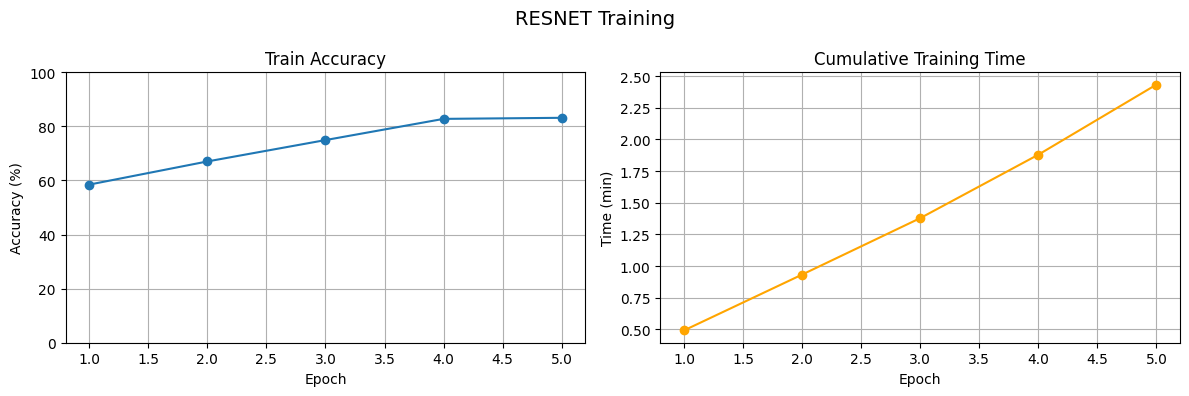

Model: cnn  |  Trainable parameters: 11,642
Epoch: 001/005 | Batch 0000/0391 | Cost: 2.3026
Epoch: 001/005 | Batch 0050/0391 | Cost: 1.9206
Epoch: 001/005 | Batch 0100/0391 | Cost: 1.8610
Epoch: 001/005 | Batch 0150/0391 | Cost: 1.8072
Epoch: 001/005 | Batch 0200/0391 | Cost: 1.8322
Epoch: 001/005 | Batch 0250/0391 | Cost: 1.7232
Epoch: 001/005 | Batch 0300/0391 | Cost: 1.4990
Epoch: 001/005 | Batch 0350/0391 | Cost: 1.5018
Epoch: 001/005 | Train Acc: 47.230%
Time elapsed: 0.12 min
Epoch: 002/005 | Batch 0000/0391 | Cost: 1.4887
Epoch: 002/005 | Batch 0050/0391 | Cost: 1.4566
Epoch: 002/005 | Batch 0100/0391 | Cost: 1.3264
Epoch: 002/005 | Batch 0150/0391 | Cost: 1.3615
Epoch: 002/005 | Batch 0200/0391 | Cost: 1.3366
Epoch: 002/005 | Batch 0250/0391 | Cost: 1.2755
Epoch: 002/005 | Batch 0300/0391 | Cost: 1.2707
Epoch: 002/005 | Batch 0350/0391 | Cost: 1.2905
Epoch: 002/005 | Train Acc: 53.790%
Time elapsed: 0.24 min
Epoch: 003/005 | Batch 0000/0391 | Cost: 1.3456
Epoch: 003/005 | Batch

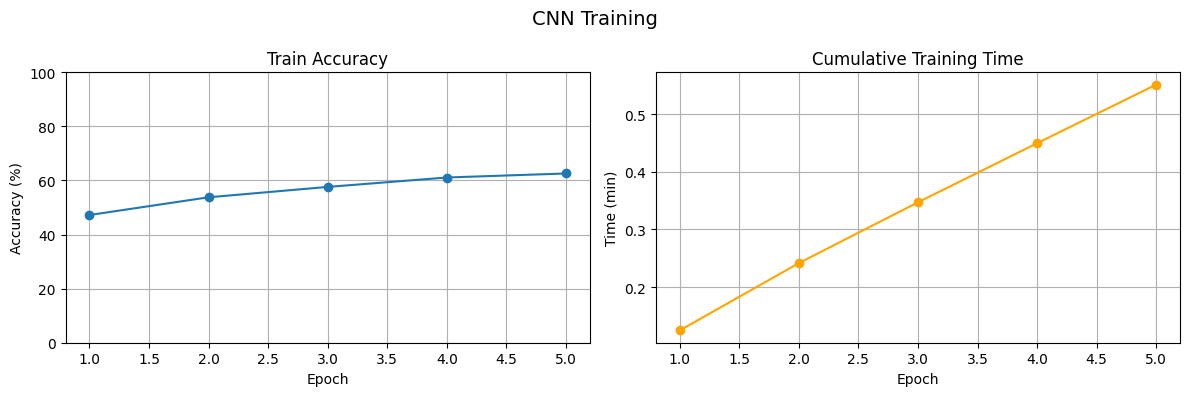

Model: mlp  |  Trainable parameters: 402,250
Epoch: 001/005 | Batch 0000/0391 | Cost: 2.3023
Epoch: 001/005 | Batch 0050/0391 | Cost: 1.8677
Epoch: 001/005 | Batch 0100/0391 | Cost: 1.8880
Epoch: 001/005 | Batch 0150/0391 | Cost: 1.8769
Epoch: 001/005 | Batch 0200/0391 | Cost: 1.7619
Epoch: 001/005 | Batch 0250/0391 | Cost: 1.6125
Epoch: 001/005 | Batch 0300/0391 | Cost: 1.6761
Epoch: 001/005 | Batch 0350/0391 | Cost: 1.5679
Epoch: 001/005 | Train Acc: 46.222%
Time elapsed: 0.11 min
Epoch: 002/005 | Batch 0000/0391 | Cost: 1.4898
Epoch: 002/005 | Batch 0050/0391 | Cost: 1.2578
Epoch: 002/005 | Batch 0100/0391 | Cost: 1.5336
Epoch: 002/005 | Batch 0150/0391 | Cost: 1.4007
Epoch: 002/005 | Batch 0200/0391 | Cost: 1.6007
Epoch: 002/005 | Batch 0250/0391 | Cost: 1.3839
Epoch: 002/005 | Batch 0300/0391 | Cost: 1.4087
Epoch: 002/005 | Batch 0350/0391 | Cost: 1.4759
Epoch: 002/005 | Train Acc: 50.390%
Time elapsed: 0.22 min
Epoch: 003/005 | Batch 0000/0391 | Cost: 1.4147
Epoch: 003/005 | Batc

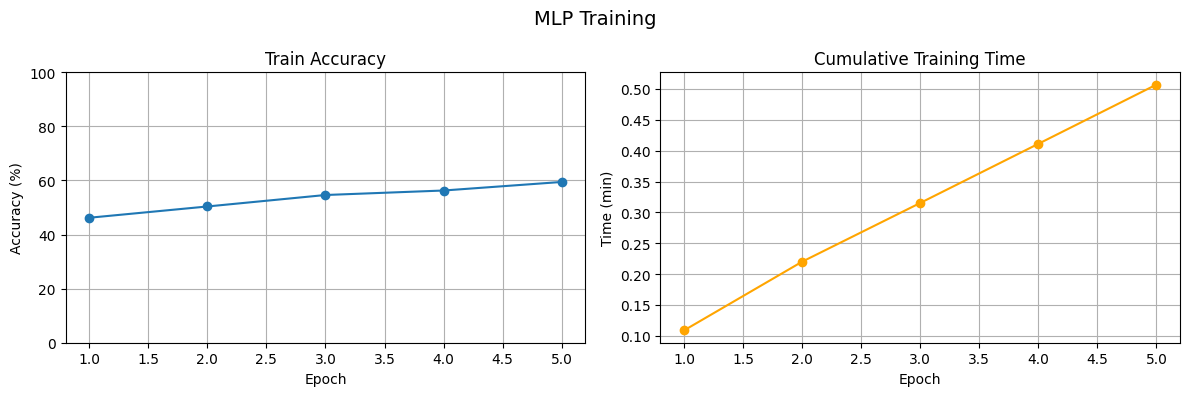

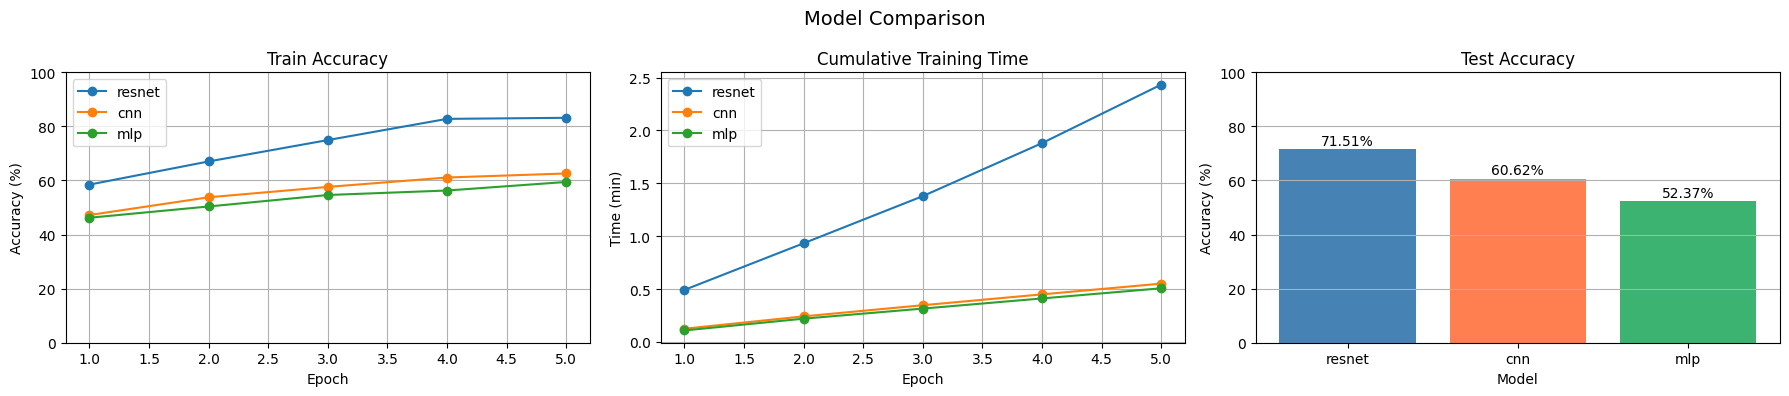

In [15]:
model_types = ['resnet', 'cnn', 'mlp']

all_results = {}

for model_type in model_types:
    tot_epoch = []
    accuracy = []
    tot_time = []
    MODEL_TYPE = model_type

    if MODEL_TYPE == 'resnet':
        model = resnet18(NUM_CLASSES)
    elif MODEL_TYPE == 'node':
        model = ODENet(num_classes=NUM_CLASSES)
    elif MODEL_TYPE == 'cnn':
        model = ConvNet(num_classes=NUM_CLASSES)
    elif MODEL_TYPE == 'mlp':
        model = MLP(num_features=NUM_FEATURES, num_classes=NUM_CLASSES)

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {MODEL_TYPE}  |  Trainable parameters: {total_params:,}")

    start_time = time.time()

    for epoch in range(NUM_EPOCHS):
        tot_epoch.append(epoch + 1)
        model.train()
        for batch_idx, (features, targets) in enumerate(train_loader):
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            logits, probas = model(features)
            cost = F.cross_entropy(logits, targets)
            optimizer.zero_grad()
            cost.backward()
            optimizer.step()

            if not batch_idx % 50:
                print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
                      % (epoch + 1, NUM_EPOCHS, batch_idx, len(train_loader), cost))

        model.eval()
        with torch.set_grad_enabled(False):
            train_acc = compute_accuracy(model, train_loader, device=DEVICE)
            print('Epoch: %03d/%03d | Train Acc: %.3f%%' % (epoch + 1, NUM_EPOCHS, train_acc))

        accuracy.append(train_acc.item())

        elapsed = (time.time() - start_time) / 60
        print('Time elapsed: %.2f min' % elapsed)
        tot_time.append(elapsed)

    print('Total Training Time: %.2f min' % ((time.time() - start_time) / 60))

    with torch.set_grad_enabled(False):
        test_acc = compute_accuracy(model, test_loader, device=DEVICE)
    print(f'[{MODEL_TYPE.upper()}] Test accuracy: {test_acc:.2f}%')

    all_results[MODEL_TYPE] = {
        'epochs': tot_epoch,
        'accuracy': accuracy,
        'time': tot_time,
        'test_accuracy': test_acc.item()  
    }

    # --- Per-model plots ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{MODEL_TYPE.upper()} Training', fontsize=14)

    axes[0].plot(tot_epoch, accuracy, marker='o')
    axes[0].set_title('Train Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_ylim(0, 100)
    axes[0].grid(True)

    axes[1].plot(tot_epoch, tot_time, marker='o', color='orange')
    axes[1].set_title('Cumulative Training Time')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Time (min)')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# --- Cross-model comparison plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Model Comparison', fontsize=14)

for name, results in all_results.items():
    axes[0].plot(results['epochs'], results['accuracy'], marker='o', label=name)
    axes[1].plot(results['epochs'], results['time'], marker='o', label=name)

axes[0].set_title('Train Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Cumulative Training Time')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Time (min)')
axes[1].legend()
axes[1].grid(True)

# --- Test accuracy bar chart ---
names = list(all_results.keys())
test_accs = [all_results[name]['test_accuracy'] for name in names]

bars = axes[2].bar(names, test_accs, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[2].set_title('Test Accuracy')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(0, 100)
axes[2].grid(True, axis='y')
for bar, acc in zip(bars, test_accs):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## For n-ode (from msurtsukov)

In [30]:
# these are for initializing n-ode
import math
import numpy as np
from IPython.display import clear_output
from tqdm import tqdm_notebook as tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.color_palette("bright")
import matplotlib as mpl
import matplotlib.cm as cm

import torch
from torch import Tensor
from torch import nn
from torch.nn  import functional as F
from torch.autograd import Variable

#### implementing the model again

In [31]:
# rk ode solver
def ode_solve(z0, t0, t1, f):
    """
    Runge-Kutta 2nd order ODE initial value solver
    """
    h_max = 0.05
    n_steps = math.ceil((abs(t1 - t0)/h_max).max().item())

    h = (t1 - t0)/n_steps
    t = t0
    z = z0

    for i_step in range(n_steps):
        f1 = f(z,t)
        f2 = f(z + (h/2) * f1, t + h/2)

        z = z + h * f2
        t = t + h

    return z


In [32]:
class ODEAdjoint(torch.autograd.Function):
    @staticmethod
    def forward(ctx, z0, t, flat_parameters, func):
        '''calling the ode solver for each time step'''
        assert isinstance(func, ODEF)
        bs, *z_shape = z0.size()
        time_len = t.size(0)

        with torch.no_grad(): #we don't save gradients for back pass like for other types of nn (we did that in the above cell)
            z = torch.zeros(time_len, bs, *z_shape).to(z0)
            z[0] = z0
            for i_t in range(time_len - 1):
                z0 = ode_solve(z0, t[i_t], t[i_t+1], func)
                z[i_t+1] = z0

        ctx.func = func
        ctx.save_for_backward(t, z.clone(), flat_parameters) #ctx is what is saved and will be used for backprop later (since we have to build a new backprop method)
        return z

    @staticmethod
    def backward(ctx, dLdz): #now we will do back prop using what we saved with ctx and find the gradient of the loss w.r.t. our IVP sol
        """
        dLdz shape: time_len, batch_size, *z_shape
        """
        func = ctx.func
        t, z, flat_parameters = ctx.saved_tensors
        time_len, bs, *z_shape = z.size()
        n_dim = np.prod(z_shape)
        n_params = flat_parameters.size(0)

        # Dynamics of augmented system to be calculated backwards in time
        def augmented_dynamics(aug_z_i, t_i):
            """
            tensors here are temporal slices
            t_i - is tensor with size: bs, 1
            aug_z_i - is tensor with size: bs, n_dim*2 + n_params + 1
            """
            z_i, a = aug_z_i[:, :n_dim], aug_z_i[:, n_dim:2*n_dim]  # ignore parameters and time

            # Unflatten z and a
            z_i = z_i.view(bs, *z_shape)
            a = a.view(bs, *z_shape)
            with torch.set_grad_enabled(True): # we are tracking gradients again since we will need it for
                t_i = t_i.detach().requires_grad_(True)
                z_i = z_i.detach().requires_grad_(True)
                # this line is when we are calculating gradients:
                func_eval, adfdz, adfdt, adfdp = func.forward_with_grad(z_i, t_i, grad_outputs=a)  # bs, *z_shape
                adfdz = adfdz.to(z_i) if adfdz is not None else torch.zeros(bs, *z_shape).to(z_i)
                adfdp = adfdp.to(z_i) if adfdp is not None else torch.zeros(bs, n_params).to(z_i)
                adfdt = adfdt.to(z_i) if adfdt is not None else torch.zeros(bs, 1).to(z_i)

            # Flatten f and adfdz
            func_eval = func_eval.view(bs, n_dim)
            adfdz = adfdz.view(bs, n_dim) 
            return torch.cat((func_eval, -adfdz, -adfdp, -adfdt), dim=1) #flatten all gradients

        dLdz = dLdz.view(time_len, bs, n_dim)  # flatten dLdz for convenience
        with torch.no_grad():
            ## Create placeholders for output gradients
            # Prev computed backwards adjoints to be adjusted by direct gradients
            adj_z = torch.zeros(bs, n_dim).to(dLdz)
            adj_p = torch.zeros(bs, n_params).to(dLdz)
            # In contrast to z and p we need to return gradients for all times
            adj_t = torch.zeros(time_len, bs, 1).to(dLdz)

            for i_t in range(time_len-1, 0, -1):
                z_i = z[i_t]
                t_i = t[i_t]
                f_i = func(z_i, t_i).view(bs, n_dim)

                # Compute direct gradients
                dLdz_i = dLdz[i_t]
                dLdt_i = torch.bmm(torch.transpose(dLdz_i.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

                # Adjusting adjoints with direct gradients
                adj_z += dLdz_i
                adj_t[i_t] = adj_t[i_t] - dLdt_i

                # Pack augmented variable
                aug_z = torch.cat((z_i.view(bs, n_dim), adj_z, torch.zeros(bs, n_params).to(z), adj_t[i_t]), dim=-1)

                # Solve augmented system backwards
                aug_ans = ode_solve(aug_z, t_i, t[i_t-1], augmented_dynamics) #calling ode solver cause for back prop we're essentially solving another ode (just back in time)

                # Unpack solved backwards augmented system
                adj_z[:] = aug_ans[:, n_dim:2*n_dim]
                adj_p[:] += aug_ans[:, 2*n_dim:2*n_dim + n_params]
                adj_t[i_t-1] = aug_ans[:, 2*n_dim + n_params:]

                del aug_z, aug_ans

            ## Adjust 0 time adjoint with direct gradients
            # Compute direct gradients 
            dLdz_0 = dLdz[0]
            dLdt_0 = torch.bmm(torch.transpose(dLdz_0.unsqueeze(-1), 1, 2), f_i.unsqueeze(-1))[:, 0]

            # Adjust adjoints
            adj_z += dLdz_0
            adj_t[0] = adj_t[0] - dLdt_0
        return adj_z.view(bs, *z_shape), adj_t, adj_p, None

In [33]:
class ODEF(nn.Module):
    def forward_with_grad(self, z, t, grad_outputs):
        """Compute f and a df/dz, a df/dp, a df/dt"""
        batch_size = z.shape[0]

        out = self.forward(z, t)

        a = grad_outputs
        #print('these are initial grad outputs :', grad_outputs)
        adfdz, adfdt, *adfdp = torch.autograd.grad(  # gradients needed to find da_aug/dt using the adjoint state
            (out,), (z, t) + tuple(self.parameters()), grad_outputs=(a),
            allow_unused=True, retain_graph=True
        )
        #print('these are grad outputs after :', grad_outputs)
        # grad method automatically sums gradients for batch items, we have to expand them back 
        if adfdp is not None:
            adfdp = torch.cat([p_grad.flatten() for p_grad in adfdp]).unsqueeze(0)
            adfdp = adfdp.expand(batch_size, -1) / batch_size
        if adfdt is not None:
            adfdt = adfdt.expand(batch_size, 1) / batch_size
        return out, adfdz, adfdt, adfdp

    def flatten_parameters(self):
        p_shapes = []
        flat_parameters = []
        for p in self.parameters():
            p_shapes.append(p.size())
            flat_parameters.append(p.flatten()) #makes 2d tensor into 1d
        return torch.cat(flat_parameters)

In [34]:
class NeuralODE(nn.Module):
    def __init__(self, func):
        super(NeuralODE, self).__init__()
        assert isinstance(func, ODEF)
        self.func = func

    def forward(self, z0, t=Tensor([0., 1.]), return_whole_sequence=False):
        t = t.to(z0)
        z = ODEAdjoint.apply(z0, t, self.func.flatten_parameters(), self.func)
        if return_whole_sequence:
            return z
        else:
            return z[-1]
        
    

#### initializing n-ode for mnist

In [35]:
def norm(dim):
    return nn.BatchNorm2d(dim)

def conv3x3(in_feats, out_feats, stride=1):
    return nn.Conv2d(in_feats, out_feats, kernel_size=3, stride=stride, padding=1, bias=False)

def add_time(in_tensor, t):
    bs, c, w, h = in_tensor.shape
    return torch.cat((in_tensor, t.expand(bs, 1, w, h)), dim=1)

In [36]:
class ConvODEF(ODEF):
    def __init__(self, dim):
        super(ConvODEF, self).__init__()
        self.conv1 = conv3x3(dim + 1, dim)
        self.norm1 = norm(dim)
        self.conv2 = conv3x3(dim + 1, dim)
        self.norm2 = norm(dim)

    def forward(self, x, t):
        xt = add_time(x, t)
        h = self.norm1(torch.relu(self.conv1(xt)))
        ht = add_time(h, t)
        dxdt = self.norm2(torch.relu(self.conv2(ht)))
        return dxdt

In [37]:
class ContinuousNeuralMNISTClassifier(nn.Module):
    def __init__(self, ode):
        super(ContinuousNeuralMNISTClassifier, self).__init__()
        self.downsampling = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1),       # 3 input channels (RGB), 32x32 -> 30x30
            norm(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 4, 2, 1),   # 30x30 -> 15x15
            norm(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 4, 2, 1),   # 15x15 -> 7x7
        )
        self.feature = ode
        self.norm = norm(64)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = self.downsampling(x)
        x = self.feature(x)
        x = self.norm(x)
        x = self.avg_pool(x)
        shape = torch.prod(torch.tensor(x.shape[1:])).item()
        x = x.view(-1, shape)
        out = self.fc(x)
        return out

In [38]:
func = ConvODEF(64)
ode = NeuralODE(func)
model = ContinuousNeuralMNISTClassifier(ode)
model = model.to(DEVICE)

In [39]:
optimizer = torch.optim.Adam(model.parameters())

#### train and test for mnist

In [40]:
optimizer = torch.optim.Adam(model.parameters())

In [41]:
def train(epoch):
    num_items = 0
    train_losses = []

    model.train()
    criterion = nn.CrossEntropyLoss()
    print(f"Training Epoch {epoch}...")
    for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):
        data = data.to(DEVICE)
        target = target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target) 
        loss.backward()
        optimizer.step()

        train_losses += [loss.item()]
        num_items += data.shape[0]
    print('Train loss: {:.5f}'.format(np.mean(train_losses)))
    return train_losses

In [42]:
def test():
    accuracy = 0.0
    num_items = 0

    model.eval()
    criterion = nn.CrossEntropyLoss()
    print(f"Testing...")
    with torch.no_grad():
        for batch_idx, (data, target) in tqdm(enumerate(test_loader),  total=len(test_loader)):
            data = data.to(DEVICE)
            target = target.to(DEVICE)
            output = model(data)
            accuracy += torch.sum(torch.argmax(output, dim=1) == target).item()
            num_items += data.shape[0]
    accuracy = accuracy * 100 / num_items
    print("Test Accuracy: {:.3f}%".format(accuracy))
    return accuracy

In [43]:
n_epochs = 5
test()
train_losses = []
tot_time_node = []
for epoch in range(1, n_epochs + 1):
    start_time = time.time()
    train_losses += train(epoch)
    test_acc = test()
    end_time = time.time()-start_time
    tot_time_node.append(end_time)

Testing...


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_20898/1405364119.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch_idx, (data, target) in tqdm(enumerate(test_loader),  total=len(test_loader)):


  0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy: 11.830%
Training Epoch 1...


/var/folders/ty/1b7rrh3s0yx8wvyxm5v17jdw0000gp/T/ipykernel_20898/1238388639.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=len(train_loader)):


...

Test Accuracy: 75.300%
Training Epoch 5...


  0%|          | 0/391 [00:00<?, ?it/s]

Train loss: 0.59053
Testing...


  0%|          | 0/79 [00:00<?, ?it/s]

Test Accuracy: 75.750%


In [44]:
all_results['node'] = {
    'epochs': tot_epoch,
    'time': tot_time_node,
    'test_accuracy': test_acc  
}

In [45]:
all_results

{'resnet': {'epochs': [1, 2, 3, 4, 5],
  'accuracy': [58.47999954223633,
   67.04399871826172,
   74.947998046875,
   82.78800201416016,
   83.18199920654297],
  'time': [0.4921119292577108,
   0.9329036474227905,
   1.378615681330363,
   1.8794984300931294,
   2.4329362312952676],
  'test_accuracy': 71.51000213623047},
 'cnn': {'epochs': [1, 2, 3, 4, 5],
  'accuracy': [47.22999954223633,
   53.78999710083008,
   57.624000549316406,
   61.104000091552734,
   62.59199905395508],
  'time': [0.12482699950536093,
   0.2415790319442749,
   0.3470274011294047,
   0.4495431661605835,
   0.5511401851971944],
  'test_accuracy': 60.619998931884766},
 'mlp': {'epochs': [1, 2, 3, 4, 5],
  'accuracy': [46.22200012207031,
   50.38999938964844,
   54.63200378417969,
   56.29399871826172,
   59.45600128173828],
  'time': [0.10853412946065268,
   0.21992144584655762,
   0.3151612321535746,
   0.41105349858601886,
   0.5070864121119182],
  'test_accuracy': 52.369998931884766},
 'node': {'epochs': [1, 2,

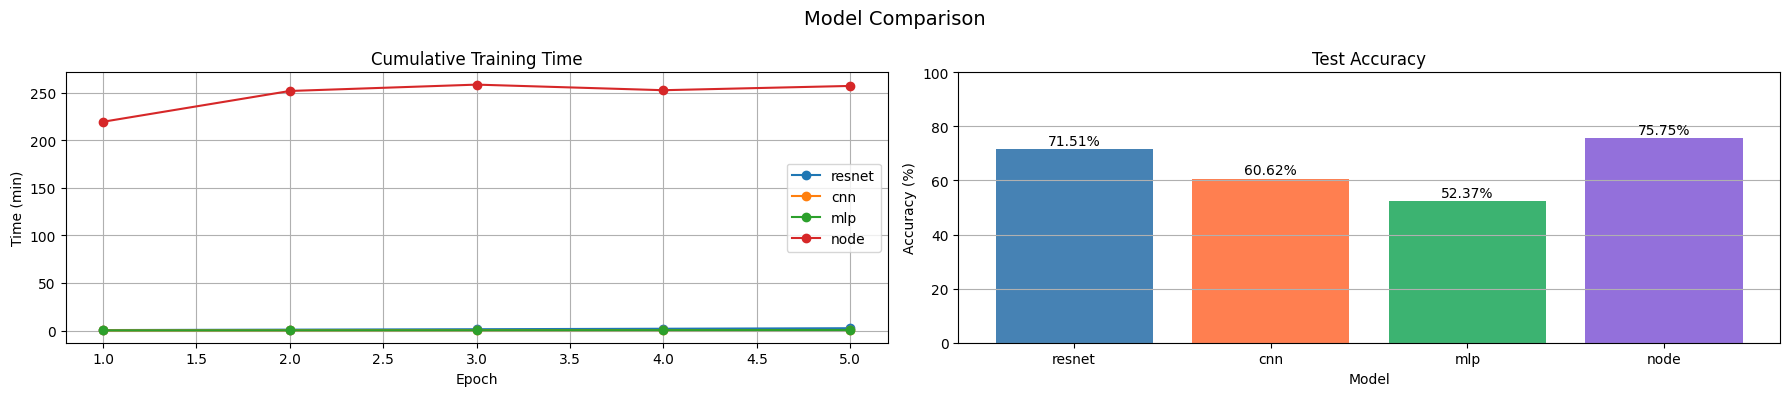

In [46]:
# --- Cross-model comparison plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
fig.suptitle('Model Comparison', fontsize=14)

for name, results in all_results.items():
    #axes[0].plot(results['epochs'], results['accuracy'], marker='o', label=name)
    axes[0].plot(results['epochs'], results['time'], marker='o', label=name)

# axes[0].set_title('Train Accuracy')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Accuracy (%)')
# axes[0].set_ylim(0, 100)
# axes[0].legend()
# axes[0].grid(True)

axes[0].set_title('Cumulative Training Time')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Time (min)')
axes[0].legend()
axes[0].grid(True)

# --- Test accuracy bar chart ---
names = list(all_results.keys())
test_accs = [all_results[name]['test_accuracy'] for name in names]

bars = axes[1].bar(names, test_accs, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].grid(True, axis='y')
for bar, acc in zip(bars, test_accs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{acc:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()